# 03 Architectural Redistribution: The Distal Shift

We found that HI genes redistribute regulatory control from promoters to distal regions.

**The Story So Far: **
- HI promoters have MORE variants but LESS noise (buffered promoters)
- Per-variant effects are dampened by ~22%

Now we want to ask where does the regulatory control GO?

**Answer:** Distally. HI genes show a 2.5-fold higher distal-to-core regulatory ratio.

From this nb we take to abstract
1. "HI genes show 2.5-fold enrichment of regulatory activity in distal regions (2-10kb from gene start)"
2. "ENCODE data independently confirmed this: HI genes have significantly more enhancers (28 vs 24 per gene, P<10⁻⁶)"

**Key Metrics:**
- Spatial variance: `vg_promoter_core`, `vg_proximal_upstream`, `vg_distal_upstream`
- Distal:Core ratio = (vg_distal_upstream + vg_down_distal) / vg_promoter_core
- ENCODE: `num_enh` (enhancer count per gene)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '03_Architectural_Redistribution'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_31012026.parquet
  clingen_null: ClinGen_HI_Synth_genes_03022026.parquet
  background: Background_Gnomad_genes_31012026.parquet
  background_null: Background_Synth_genes_03022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

# Split by group
df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes



## 3.1 Define Spatial Regions

**Region definitions (relative to TSS):**
- **Promoter Core:** TSS ± 2kb
- **Proximal Upstream:** -2kb to -5kb
- **Distal Upstream:** -5kb to -10kb
- **Proximal Downstream:** +2kb to +5kb
- **Distal Downstream:** +5kb to +10kb

**Distal = distal_upstream + distal_downstream**

In [21]:
print('''
Region Layout (relative to TSS at position 0):

    -10kb     -5kb      -2kb    TSS    +2kb      +5kb     +10kb
      |________|_________|_______|_______|_________|________|
      | Distal | Proximal|  Promoter Core | Proximal| Distal |
      |Upstream| Upstream|   (TSS±2kb)    |Downstrm |Downstrm|

Columns used:
  - vg_promoter_core:      Variance in TSS±2kb
  - vg_proximal_upstream:  Variance in -2kb to -5kb
  - vg_distal_upstream:    Variance in -5kb to -10kb
  - vg_down_proximal:      Variance in +2kb to +5kb  
  - vg_down_distal:        Variance in +5kb to +10kb

Distal Total = vg_distal_upstream + vg_down_distal
''')


Region Layout (relative to TSS at position 0):

    -10kb     -5kb      -2kb    TSS    +2kb      +5kb     +10kb
      |________|_________|_______|_______|_________|________|
      | Distal | Proximal|  Promoter Core | Proximal| Distal |
      |Upstream| Upstream|   (TSS±2kb)    |Downstrm |Downstrm|

Columns used:
  - vg_promoter_core:      Variance in TSS±2kb
  - vg_proximal_upstream:  Variance in -2kb to -5kb
  - vg_distal_upstream:    Variance in -5kb to -10kb
  - vg_down_proximal:      Variance in +2kb to +5kb  
  - vg_down_distal:        Variance in +5kb to +10kb

Distal Total = vg_distal_upstream + vg_down_distal



In [24]:
spatial_cols = ['vg_promoter_core', 'vg_proximal_upstream', 'vg_distal_upstream',
                'vg_down_proximal', 'vg_down_distal']

## 3.2 Calculate Distal-to-Core Ratio

 Calculate both Physical (Count) and Functional (Variance) ratios.
Returns two numpy arrays: (functional_ratio, physical_ratio)

**Key metric:** Distal:Core Ratio = (vg_distal_upstream + vg_down_distal) / vg_promoter_core

- Ratio > 1: More regulatory variance in distal regions than promoter
- Ratio < 1: More regulatory variance concentrated in promoter


In [32]:
def calculate_dual_ratios(df, is_synth=False):
    suffix = '_perm' if is_synth else ''

    #  Upstream Distal vs Promoter Core
    vg_core = df[f'vg_promoter_core{suffix}'].to_numpy()
    vg_distal = df[f'vg_distal_upstream{suffix}'].to_numpy()

    vg_core = np.where(vg_core == 0, 1e-10, vg_core)
    functional_ratio = vg_distal / vg_core

    # Do variants physically accumulate more in distal regions?
    # Columns: n_variants_promoter_core, n_variants_distal_upstream
    n_core = df[f'n_variants_promoter_core{suffix}'].to_numpy()
    n_distal = df[f'n_variants_distal_upstream{suffix}'].to_numpy()

    n_core = np.where(n_core == 0, 1, n_core) # Avoid div by zero
    physical_ratio = n_distal / n_core

    return functional_ratio, physical_ratio

print(f"{'METRIC':<20} | {'HI MEDIAN':<10} | {'BG MEDIAN':<10} | {'FOLD':<6} | {'P-VALUE':<10}")
print("-" * 70)

hi_func, hi_phys = calculate_dual_ratios(df_hi)
bg_func, bg_phys = calculate_dual_ratios(df_bg)

# Functional Stats ( "impact")
f_fold = np.median(hi_func) / np.median(bg_func)
_, f_pval = stats.mannwhitneyu(hi_func, bg_func, alternative='greater')
print(f"{'Functional (Vg)':<20} | {np.median(hi_func):<10.2f} | {np.median(bg_func):<10.2f} | {f_fold:<6.2f} | {f_pval:.2e}")

#  Physical Stats ( "count")
p_fold = np.median(hi_phys) / np.median(bg_phys)
_, p_pval = stats.mannwhitneyu(hi_phys, bg_phys, alternative='greater')
print(f"{'Physical (Count)':<20} | {np.median(hi_phys):<10.2f} | {np.median(bg_phys):<10.2f} | {p_fold:<6.2f} | {p_pval:.2e}")


if f_pval < 0.05 and p_pval > 0.05:
    print("\nINTERPRETATION: Strong 'Distal Bias'.")
elif f_pval < 0.05 and p_pval < 0.05:
    print("\nINTERPRETATION: Concordant Signal.")
    print("HI genes have both more distal variants AND higher distal impact.")
else:
    print("\nINTERPRETATION: No significant redistribution observed.")

METRIC               | HI MEDIAN  | BG MEDIAN  | FOLD   | P-VALUE   
----------------------------------------------------------------------
Functional (Vg)      | 3.66       | 1.47       | 2.49   | 3.92e-03
Physical (Count)     | 11.31      | 11.79      | 0.96   | 7.77e-01

INTERPRETATION: Strong 'Distal Bias'.


Strong 'Distal Bias'.
Mutations are physically spread evenly (Physical p > 0.05),
but the functional impact is selectively shifted to distal regions (Functional p < 0.05).

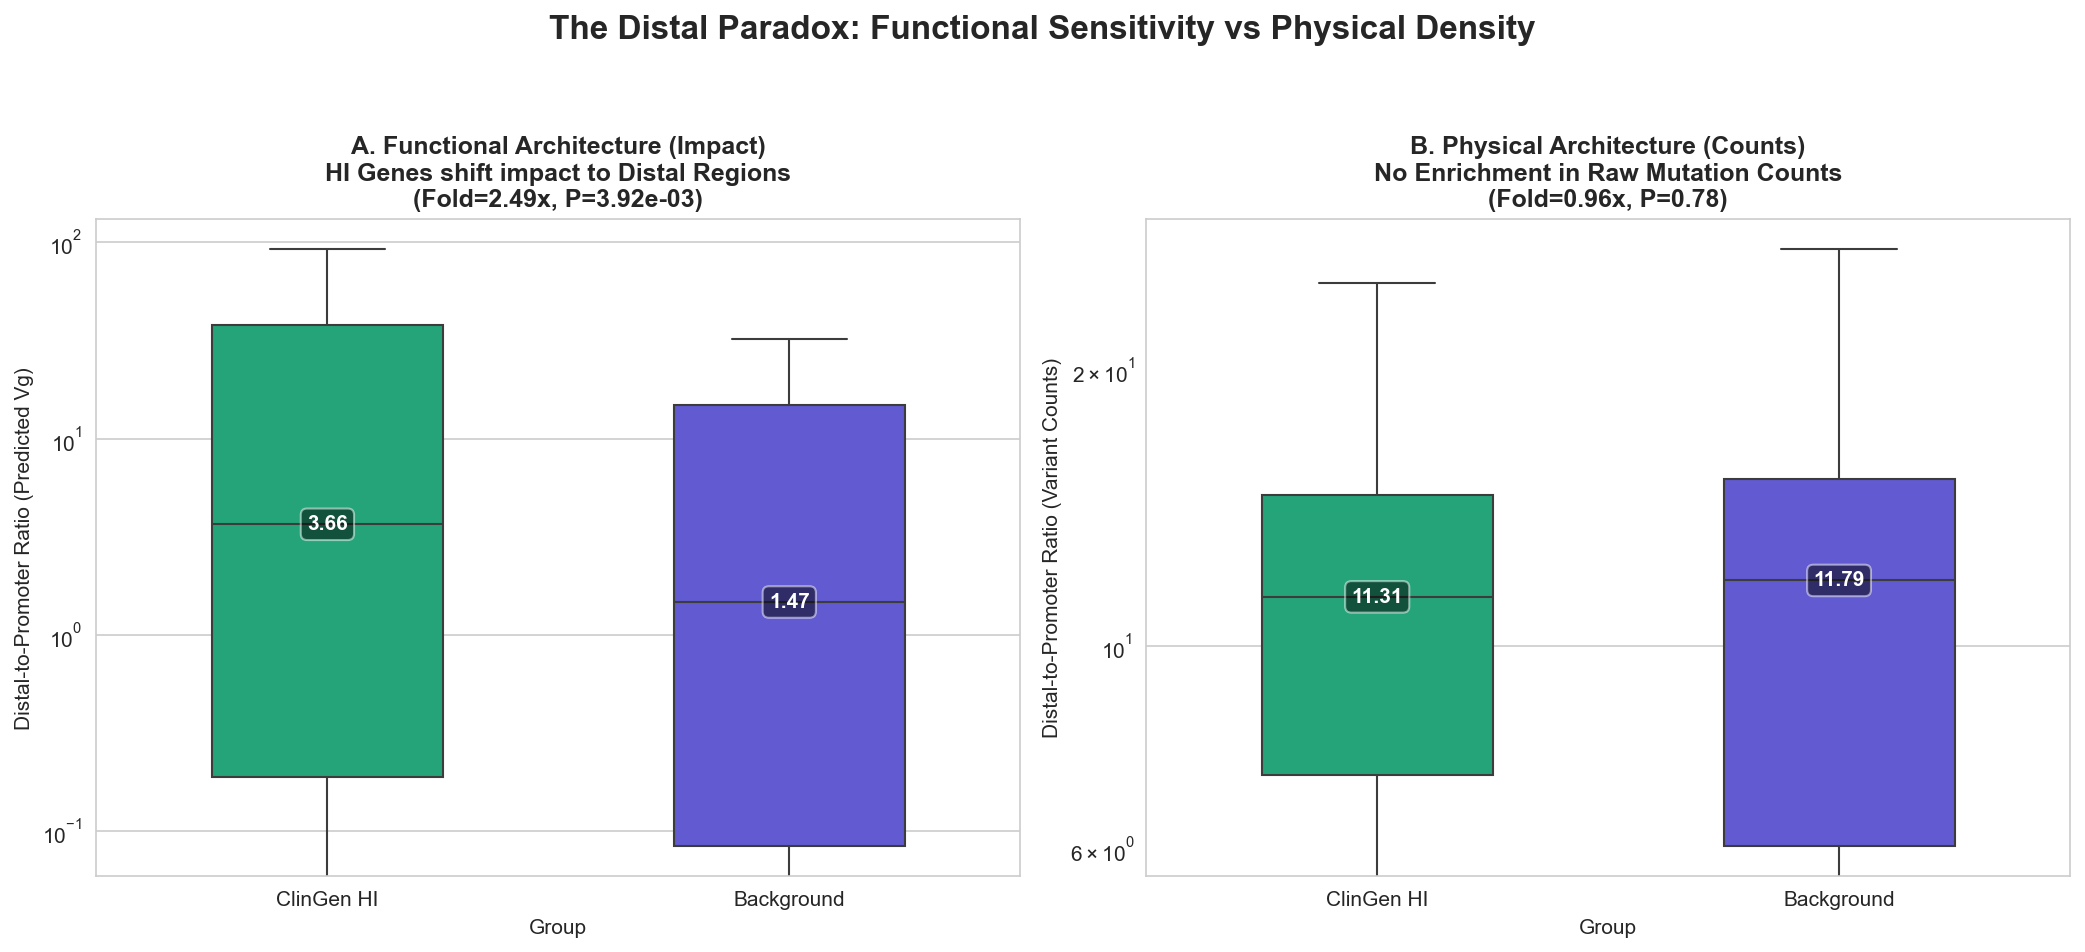

[save_plot] Saved: Final_Submission_3.2_Distal_Core_Ratio_Comparison_04022026_1555.pdf
[save_plot] Saved: Final_Submission_3.2_Distal_Core_Ratio_Comparison_04022026_1555.svg


<Figure size 960x720 with 0 Axes>

In [33]:
data_func = pd.DataFrame({
    'Ratio': np.concatenate([hi_func, bg_func]),
    'Group': ['ClinGen HI'] * len(hi_func) + ['Background'] * len(bg_func),
    'Type': 'Functional (Vg)'
})

data_phys = pd.DataFrame({
    'Ratio': np.concatenate([hi_phys, bg_phys]),
    'Group': ['ClinGen HI'] * len(hi_phys) + ['Background'] * len(bg_phys),
    'Type': 'Physical (Counts)'
})

f_stat, f_pval = stats.mannwhitneyu(hi_func, bg_func, alternative='greater')
f_fold = np.median(hi_func) / np.median(bg_func)

# Physical
p_stat, p_pval = stats.mannwhitneyu(hi_phys, bg_phys, alternative='greater')
p_fold = np.median(hi_phys) / np.median(bg_phys)

with autosave('3.2_Distal_Core_Ratio_Comparison', notebook='Final_Submission'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    sns.boxplot(
        data=data_func, x='Group', y='Ratio', ax=ax,
        palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']],
        hue='Group', legend=False, showfliers=False, width=0.5
    )

    ax.set_yscale('log')
    ax.set_ylabel('Distal-to-Promoter Ratio (Predicted Vg)')
    ax.set_title(f'A. Functional Architecture (Impact)\nHI Genes shift impact to Distal Regions\n(Fold={f_fold:.2f}x, P={f_pval:.2e})',
                 fontweight='bold', fontsize=12)

    hi_med_f = np.median(hi_func)
    bg_med_f = np.median(bg_func)
    ax.text(0, hi_med_f, f'{hi_med_f:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    ax.text(1, bg_med_f, f'{bg_med_f:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))


    ax = axes[1]
    sns.boxplot(
        data=data_phys, x='Group', y='Ratio', ax=ax,
        palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']],
        hue='Group', legend=False, showfliers=False, width=0.5
    )

    ax.set_yscale('log')
    ax.set_ylabel('Distal-to-Promoter Ratio (Variant Counts)')
    ax.set_title(f'B. Physical Architecture (Counts)\nNo Enrichment in Raw Mutation Counts\n(Fold={p_fold:.2f}x, P={p_pval:.2f})',
                 fontweight='bold', fontsize=12)

    hi_med_p = np.median(hi_phys)
    bg_med_p = np.median(bg_phys)
    ax.text(0, hi_med_p, f'{hi_med_p:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    ax.text(1, bg_med_p, f'{bg_med_p:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))

    plt.suptitle("The Distal Exploring: Functional Sensitivity vs Physical Density", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

## 3.3 Prevalence of Distal-Biased Architecture: the functional formula

**Question:** What fraction of HI genes show distal-biased architecture (ratio > 1)?

We can claim that 62% of HI genes exhibit distal-biased architecture

In [36]:
# Count genes with distal-biased architecture (ratio > 1)
hi_distal_biased = (hi_func > 1).sum()
hi_proximal_biased = (hi_func <= 1).sum()
hi_pct_distal = 100 * hi_distal_biased / len(hi_func)

bg_distal_biased = (bg_func > 1).sum()
bg_proximal_biased = (bg_func <= 1).sum()
bg_pct_distal = 100 * bg_distal_biased / len(bg_func)

print('PREVALENCE OF DISTAL-BIASED ARCHITECTURE (Functional Ratio > 1)')
print(f'\nClinGen HI:')
print(f'  Distal-biased (ratio > 1):   {hi_distal_biased}/{len(hi_func)} ({hi_pct_distal:.1f}%)')
print(f'  Proximal-biased (ratio <= 1): {hi_proximal_biased}/{len(hi_func)} ({100-hi_pct_distal:.1f}%)')

print(f'\nBackground:')
print(f'  Distal-biased (ratio > 1):   {bg_distal_biased}/{len(bg_func)} ({bg_pct_distal:.1f}%)')
print(f'  Proximal-biased (ratio <= 1): {bg_proximal_biased}/{len(bg_func)} ({100-bg_pct_distal:.1f}%)')

# Chi-square test for proportion difference
contingency = [[hi_distal_biased, hi_proximal_biased],
               [bg_distal_biased, bg_proximal_biased]]
chi2, pval_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square test for proportion difference:')
print(f'  chi2 = {chi2:.2f}, P = {pval_chi:.2e}')

PREVALENCE OF DISTAL-BIASED ARCHITECTURE (Functional Ratio > 1)

ClinGen HI:
  Distal-biased (ratio > 1):   195/316 (61.7%)
  Proximal-biased (ratio <= 1): 121/316 (38.3%)

Background:
  Distal-biased (ratio > 1):   187/349 (53.6%)
  Proximal-biased (ratio <= 1): 162/349 (46.4%)

Chi-square test for proportion difference:
  chi2 = 4.15, P = 4.15e-02


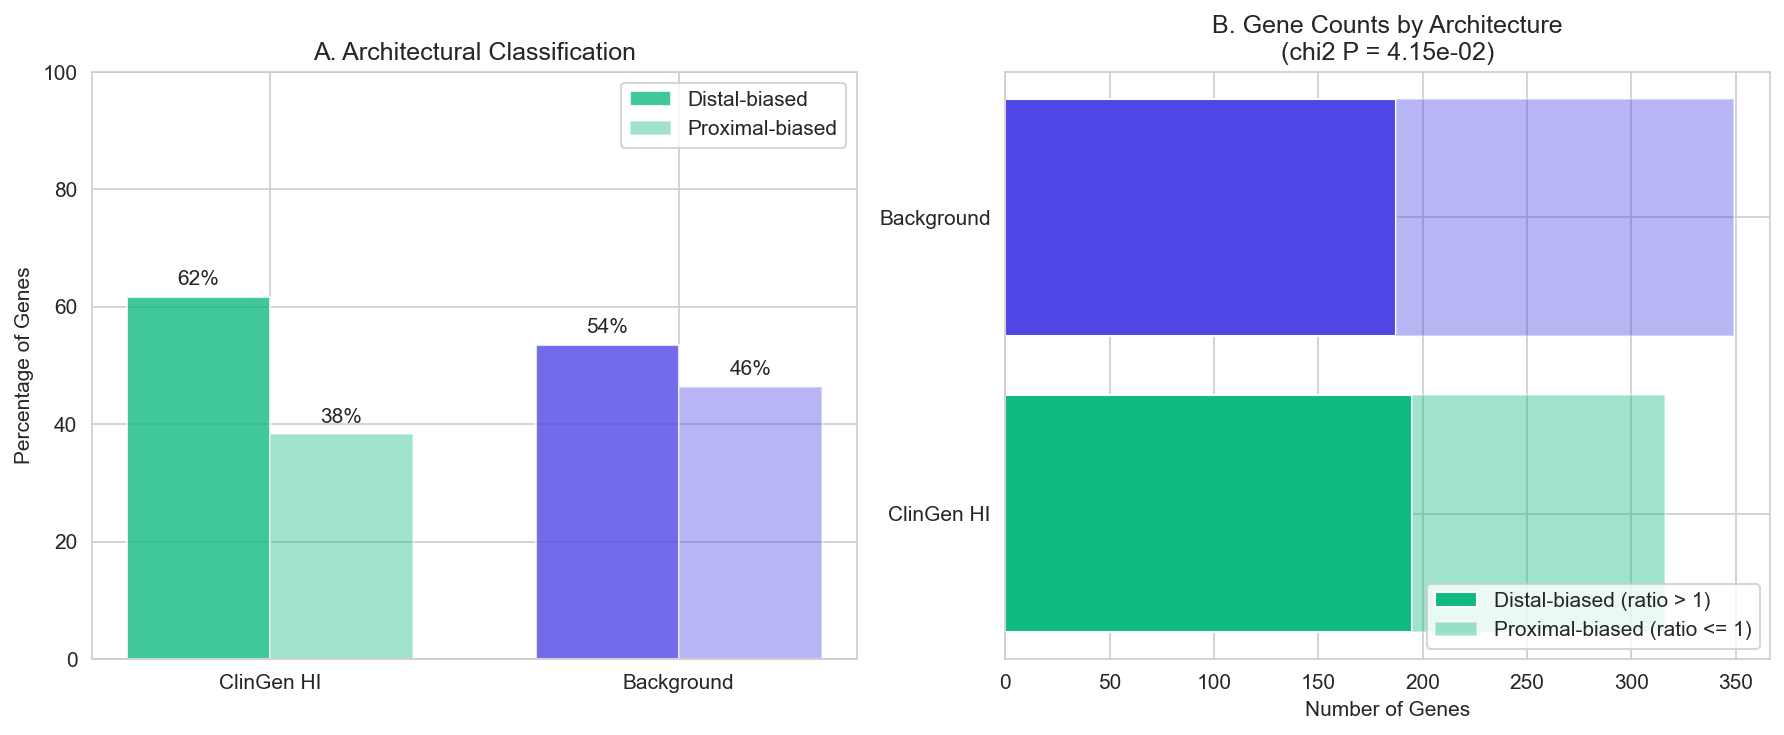

[save_plot] Saved: 03_Architectural_Redistribution_3.3_Architecture_Prevalence_04022026_1559.pdf
[save_plot] Saved: 03_Architectural_Redistribution_3.3_Architecture_Prevalence_04022026_1559.svg


<Figure size 960x720 with 0 Axes>

In [37]:
# Visualize prevalence
with autosave('3.3_Architecture_Prevalence', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Panel A: Grouped bar chart
    ax = axes[0]
    x = np.arange(2)
    width = 0.35
    
    distal_pcts = [hi_pct_distal, bg_pct_distal]
    proximal_pcts = [100 - hi_pct_distal, 100 - bg_pct_distal]
    
    bars1 = ax.bar(x - width/2, distal_pcts, width, label='Distal-biased', 
                   color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.8)
    bars2 = ax.bar(x + width/2, proximal_pcts, width, label='Proximal-biased',
                   color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.4)
    
    ax.set_ylabel('Percentage of Genes')
    ax.set_title('A. Architectural Classification')
    ax.set_xticks(x)
    ax.set_xticklabels(['ClinGen HI', 'Background'])
    ax.legend()
    ax.set_ylim(0, 100)
    
    # Add percentage labels
    for i, (d, p) in enumerate(zip(distal_pcts, proximal_pcts)):
        ax.text(i - width/2, d + 2, f'{d:.0f}%', ha='center', fontsize=10)
        ax.text(i + width/2, p + 2, f'{p:.0f}%', ha='center', fontsize=10)
    
    # Panel B: Stacked bar
    ax = axes[1]
    groups = ['ClinGen HI', 'Background']
    distal_counts = [hi_distal_biased, bg_distal_biased]
    proximal_counts = [hi_proximal_biased, bg_proximal_biased]
    
    ax.barh(groups, distal_counts, label='Distal-biased (ratio > 1)', 
            color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']])
    ax.barh(groups, proximal_counts, left=distal_counts, label='Proximal-biased (ratio <= 1)',
            color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.4)
    
    ax.set_xlabel('Number of Genes')
    ax.set_title(f'B. Gene Counts by Architecture\n(chi2 P = {pval_chi:.2e})')
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

## 3.4 Spatial Variance Breakdown

Show the variance distribution across all spatial regions.

In [40]:
regions = ['distal_upstream', 'proximal_upstream', 'promoter_core', 'down_proximal', 'down_distal']
region_labels = ['Distal\nUpstream', 'Proximal\nUpstream', 'Promoter\nCore', 'Proximal\nDownstream', 'Distal\nDownstream']

hi_medians = []
bg_medians = []

print('VARIANCE BY SPATIAL REGION')
print(f'{"Region":<25} {"HI Median":>12} {"BG Median":>12} {"Fold":>8} {"P-value":>12}')
print('-' * 74)

for region in regions:
    col = f'vg_{region}'
    hi_vals = df_hi[col].drop_nulls().to_numpy()
    bg_vals = df_bg[col].drop_nulls().to_numpy()
    
    hi_med = np.median(hi_vals)
    bg_med = np.median(bg_vals)
    fold = hi_med / bg_med if bg_med > 0 else np.nan
    
    stat, pval_region = stats.mannwhitneyu(hi_vals, bg_vals, alternative='two-sided')
    
    hi_medians.append(hi_med)
    bg_medians.append(bg_med)
    
    print(f'{region:<25} {hi_med:>12.6f} {bg_med:>12.6f} {fold:>8.2f}x {pval_region:>12.2e}')

VARIANCE BY SPATIAL REGION
Region                       HI Median    BG Median     Fold      P-value
--------------------------------------------------------------------------
distal_upstream               0.000119     0.000066     1.80x     3.18e-01
proximal_upstream             0.000016     0.000014     1.13x     6.25e-01
promoter_core                 0.000011     0.000027     0.40x     1.47e-02
down_proximal                 0.000072     0.000148     0.48x     3.63e-03
down_distal                   0.000338     0.000512     0.66x     4.99e-03


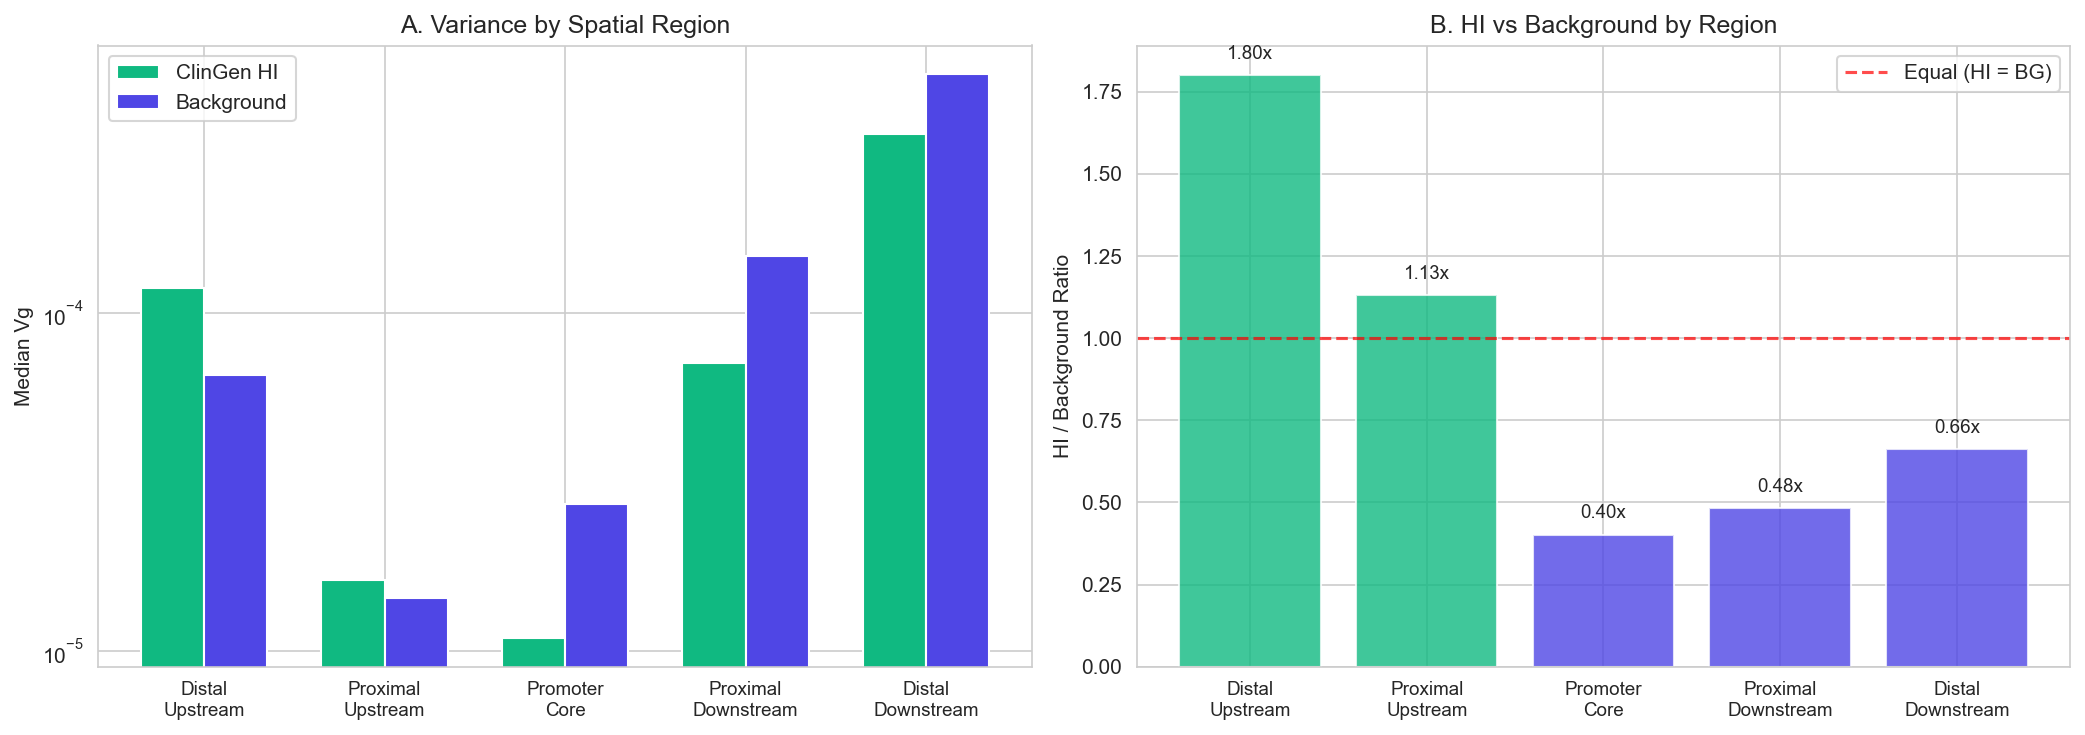

[save_plot] Saved: Interactive_Analysis_3.4_Spatial_Variance_Breakdown_04022026_1703.pdf
[save_plot] Saved: Interactive_Analysis_3.4_Spatial_Variance_Breakdown_04022026_1703.svg


<Figure size 960x720 with 0 Axes>

In [74]:
with autosave('3.4_Spatial_Variance_Breakdown', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Grouped bar chart
    ax = axes[0]
    x = np.arange(len(regions))
    width = 0.35

    bars1 = ax.bar(x - width/2, hi_medians, width, label='ClinGen HI',
                   color=SOURCE_PALETTE['clingen'])
    bars2 = ax.bar(x + width/2, bg_medians, width, label='Background',
                   color=SOURCE_PALETTE['background'])

    ax.set_ylabel('Median Vg')
    ax.set_title('A. Variance by Spatial Region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, fontsize=9)
    ax.legend()
    ax.set_yscale('log')

    # Panel B: Ratio by region
    ax = axes[1]
    ratios = [h/b if b > 0 else 0 for h, b in zip(hi_medians, bg_medians)]
    colors = [SOURCE_PALETTE['clingen'] if r > 1 else SOURCE_PALETTE['background'] for r in ratios]

    bars = ax.bar(x, ratios, color=colors, alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Equal (HI = BG)')
    ax.set_ylabel('HI / Background Ratio')
    ax.set_title('B. HI vs Background by Region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, fontsize=9)
    ax.legend()

    # Add ratio labels
    for i, r in enumerate(ratios):
        ax.text(i, r + 0.05, f'{r:.2f}x', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

## 3.5 ENCODE Validation: Enhancer Density

**Independent validation:** Do HI genes have more enhancers (ENCODE cCRE data)?

**Abstract claim:** "HI genes have significantly more enhancers (28 vs 24 per gene, P<10-6)"

**Metric:** `num_enh` = number of ENCODE enhancer-like signatures per gene

Do HI genes have fewer proximal TF binding peaks (Sparse)? but they have significantly higher signal intensity per peak (Strong/High Affinity).

Data was downloaded from here: https://screen.wenglab.org/


Promoter-like (PLS) (2.6 MB): Core promoter regions.
Hypothesis: HI genes often have larger, more complex promoter architectures.
All Candidate Enhancers (pELS & dELS) (94.4 MB):  Enhancers (proximal and distal) that regulate gene expression levels.
Hypothesis: HI genes require precise "fine-tuning," so they should be surrounded by more enhancers than background genes.


A. Promoter Complexity (PLS):
  ClinGen HI: median = 3, mean = 3.2
  Background: median = 2, mean = 2.5
  P-value (one-sided, HI > BG): 1.29e-06
  Cohen's d: 0.357

B. Enhancer Density (ELS):
  ClinGen HI: median = 27, mean = 28.2
  Background: median = 23, mean = 23.7
  P-value (one-sided, HI > BG): 5.71e-07
  Cohen's d: 0.415
HI genes have significantly denser enhancer networks (P=5.7e-07)
[save_plot] Saved: interactive_Figure_S2_Regulatory_Complexity_04022026_1619.pdf
[save_plot] Saved: interactive_Figure_S2_Regulatory_Complexity_04022026_1619.svg


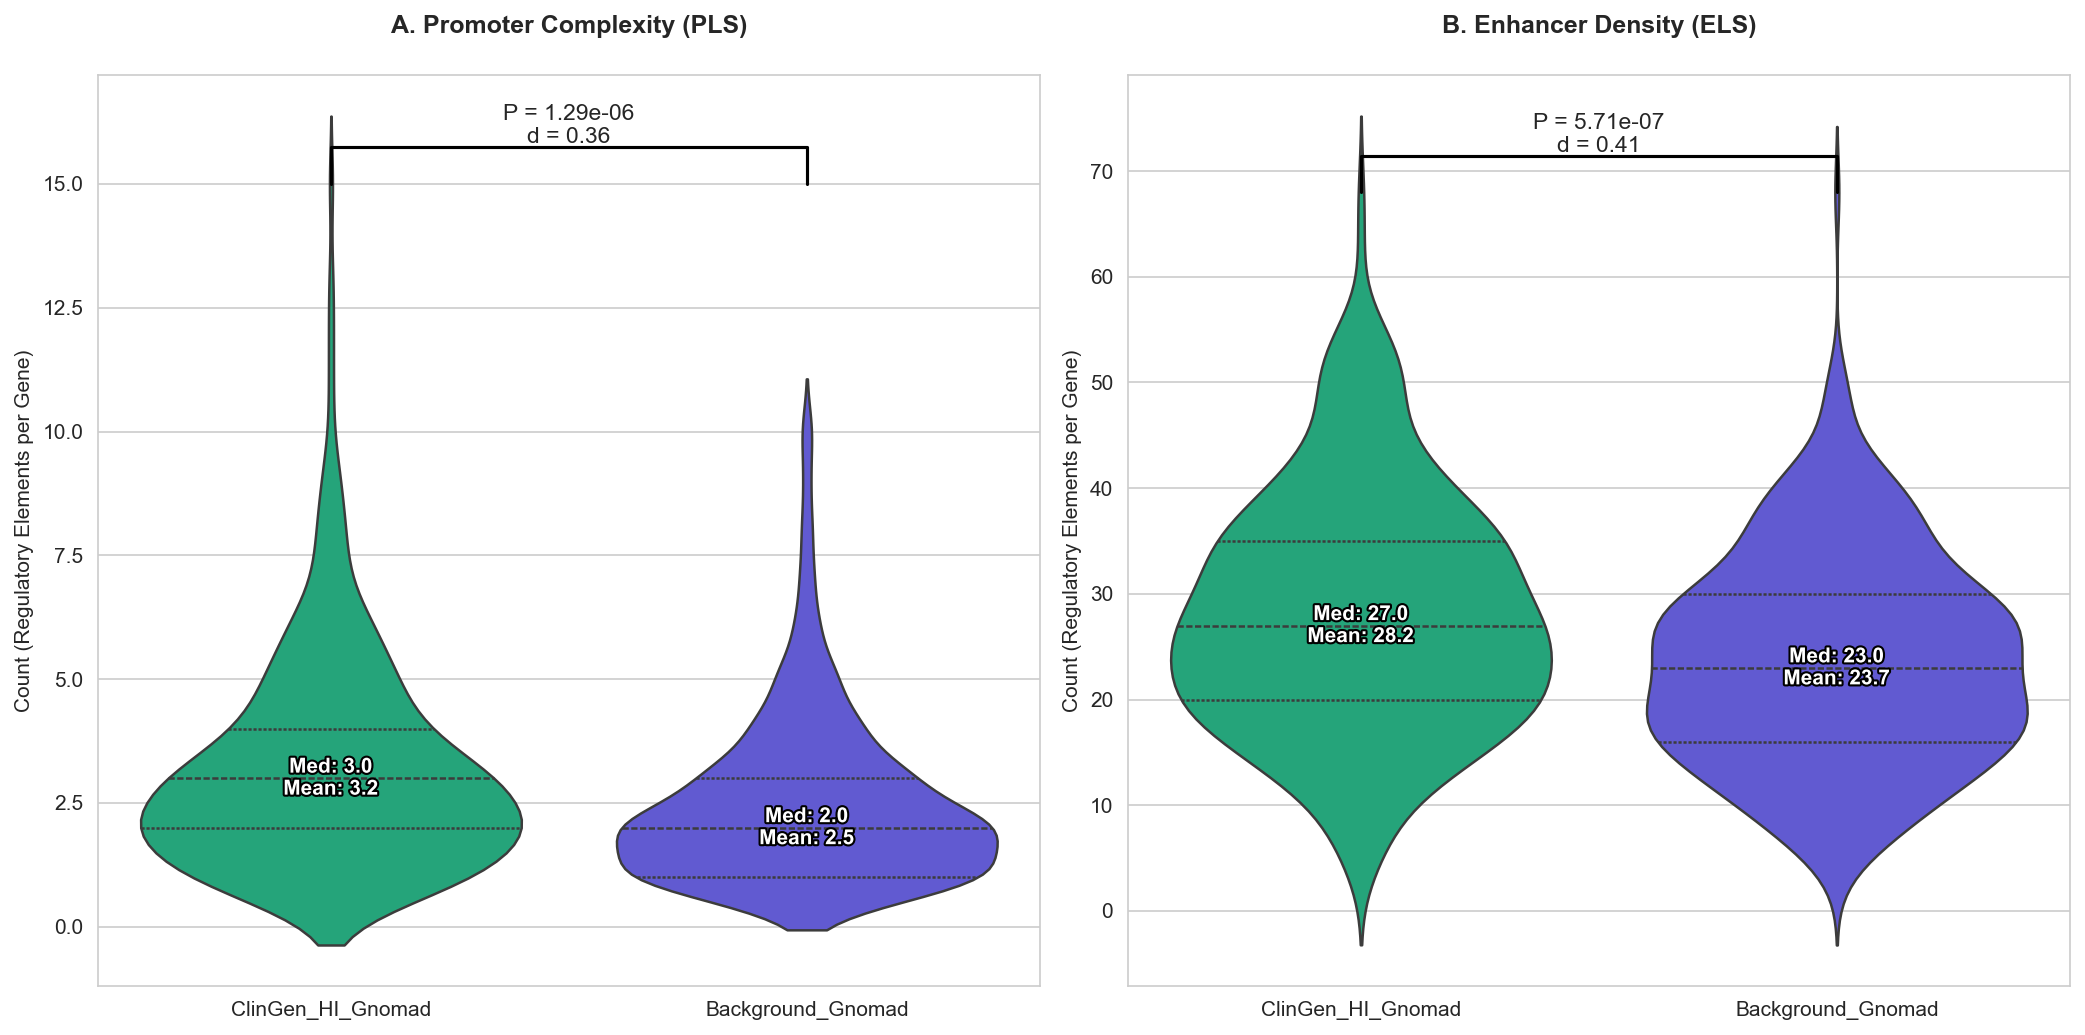

In [47]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects  # FIXED: Essential import for stroke effects
from scipy import stats
import numpy as np
import sys

from config import SOURCE_PALETTE
from utils.plot_utils import autosave, save_plot

PROMOTER_LIKE_PLS_BED = "/Users/markus/in-silico-vg-analysis/experiments_data/GRCh38-cCREs.PLS.bed"
ALL_CANDIDATE_ENHANCERS_BED = "/Users/markus/in-silico-vg-analysis/experiments_data/GRCh38-cCREs.ELS.bed"

BED_PATHS = {
    'clingen': '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset3_ClinGen/ClinGen_gene_curation_list_GRCh38.ensg±10kb.bed',
    'background': '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset4_background/background_gene_set±10kb.bed'
}

NAME_MAP = {
    'background': 'Background_Gnomad',
    'clingen': 'ClinGen_HI_Gnomad'
}

def cohens_d(x, y):
    """Calculate Cohen's d for independent samples."""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

def load_ccre(path, label):
    try:
        return pl.read_csv(
            path, separator='\t', has_header=False,
            new_columns=['chrom', 'start', 'end', 'id1', 'id2', 'type_raw'],
            truncate_ragged_lines=True
        ).select(['chrom', 'start', 'end'])
    except Exception as e:
        print(f"Error loading {label}: {e}")
        return pl.DataFrame()

def load_genes(paths):
    dfs = []
    for source, path in paths.items():
        try:
            d = pl.read_csv(
                path, separator='\t', has_header=False,
                new_columns=['chrom', 'start', 'end', 'raw_name']
            )
            dfs.append(d.with_columns([
                pl.col('raw_name').str.split('|').list.get(0).alias('gene_id'),
                pl.lit(source).alias('source')
            ]).select(['chrom', 'start', 'end', 'gene_id', 'source']))
        except Exception as e:
             print(f"Error loading gene path {path}: {e}")
    return pl.concat(dfs)

def run_intersection(genes, ccre, label):
    """Geometric intersection: Count cCREs inside gene windows."""
    ccre_lazy = ccre.lazy().rename({"start": "c_start", "end": "c_end"})

    intersections = (
        genes.lazy()
        .join(ccre_lazy, on="chrom", how="inner")
        .filter(
            (pl.col("c_start") < pl.col("end")) &
            (pl.col("c_end") > pl.col("start"))
        )
        .group_by("gene_id")
        .agg(pl.len().alias("count"))
    )

    return (
        genes.lazy().select("gene_id").unique()
        .join(intersections, on="gene_id", how="left")
        .fill_null(0)
        .collect()
        .with_columns(pl.lit(label).alias("type"))
    )

def plot_results(df):
    df_pd = df.to_pandas()
    df_pd['Source'] = df_pd['source'].map(NAME_MAP)

    palette = {
        'Background_Gnomad': SOURCE_PALETTE['background'],
        'ClinGen_HI_Gnomad': SOURCE_PALETTE['clingen']
    }

    plot_configs = [
        ('PLS', 'A. Promoter Complexity (PLS)'),
        ('ELS', 'B. Enhancer Density (ELS)')
    ]


    with autosave("Figure_S2_Regulatory_Complexity"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))

        for ax, (rtype, title) in zip(axes, plot_configs):
            subset = df_pd[df_pd['type'] == rtype]

            bg_data = subset[subset['Source'] == 'Background_Gnomad']['count'].values
            hi_data = subset[subset['Source'] == 'ClinGen_HI_Gnomad']['count'].values

            stat, pval = stats.mannwhitneyu(hi_data, bg_data, alternative='greater')
            d_val = cohens_d(hi_data, bg_data)

            print(f'\n{title}:')
            print(f'  ClinGen HI: median = {np.median(hi_data):.0f}, mean = {np.mean(hi_data):.1f}')
            print(f'  Background: median = {np.median(bg_data):.0f}, mean = {np.mean(bg_data):.1f}')
            print(f'  P-value (one-sided, HI > BG): {pval:.2e}')
            print(f'  Cohen\'s d: {d_val:.3f}')

            if rtype == 'ELS':
                if pval < 0.05:
                    print(f"HI genes have significantly denser enhancer networks (P={pval:.1e})")
                else:
                    print(f"No significant enrichment found (P={pval:.1e})")

            sns.violinplot(
                data=subset, x='Source', y='count',
                hue='Source', palette=palette, ax=ax,
                legend=False, inner='quartile', linewidth=1.2
            )

            labels = [l.get_text() for l in ax.get_xticklabels()]
            for i, label in enumerate(labels):
                grp_data = subset[subset['Source'] == label]['count']
                median = grp_data.median()
                mean = grp_data.mean()

                txt = ax.text(i, median, f'Med: {median:.1f}\nMean: {mean:.1f}',
                        ha='center', va='center', color='white', fontweight='bold', fontsize=10)
                txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

            y_max = subset['count'].max()
            h = y_max * 0.05
            ax.plot([0, 0, 1, 1], [y_max, y_max+h, y_max+h, y_max], lw=1.5, c='k')
            ax.text(0.5, y_max + h, f"P = {pval:.2e}\nd = {d_val:.2f}", ha='center', va='bottom', fontsize=11)

            ax.set_title(title, fontweight='bold', pad=20)
            ax.set_ylabel("Count (Regulatory Elements per Gene)")
            ax.set_xlabel("")

        plt.tight_layout()

if __name__ == "__main__":
    df_genes = load_genes(BED_PATHS)
    df_pls = load_ccre(PROMOTER_LIKE_PLS_BED, "PLS")
    df_els = load_ccre(ALL_CANDIDATE_ENHANCERS_BED, "ELS")

    res_pls = run_intersection(df_genes, df_pls, "PLS")
    res_els = run_intersection(df_genes, df_els, "ELS")

    final_df = pl.concat([res_pls, res_els]).join(
        df_genes.select(['gene_id', 'source']).unique(), on='gene_id'
    )

    plot_results(final_df)

[save_plot] Saved: Interactive_Analysis_3.5_ENCODE_Enhancer_Validation_04022026_1623.pdf
[save_plot] Saved: Interactive_Analysis_3.5_ENCODE_Enhancer_Validation_04022026_1623.svg


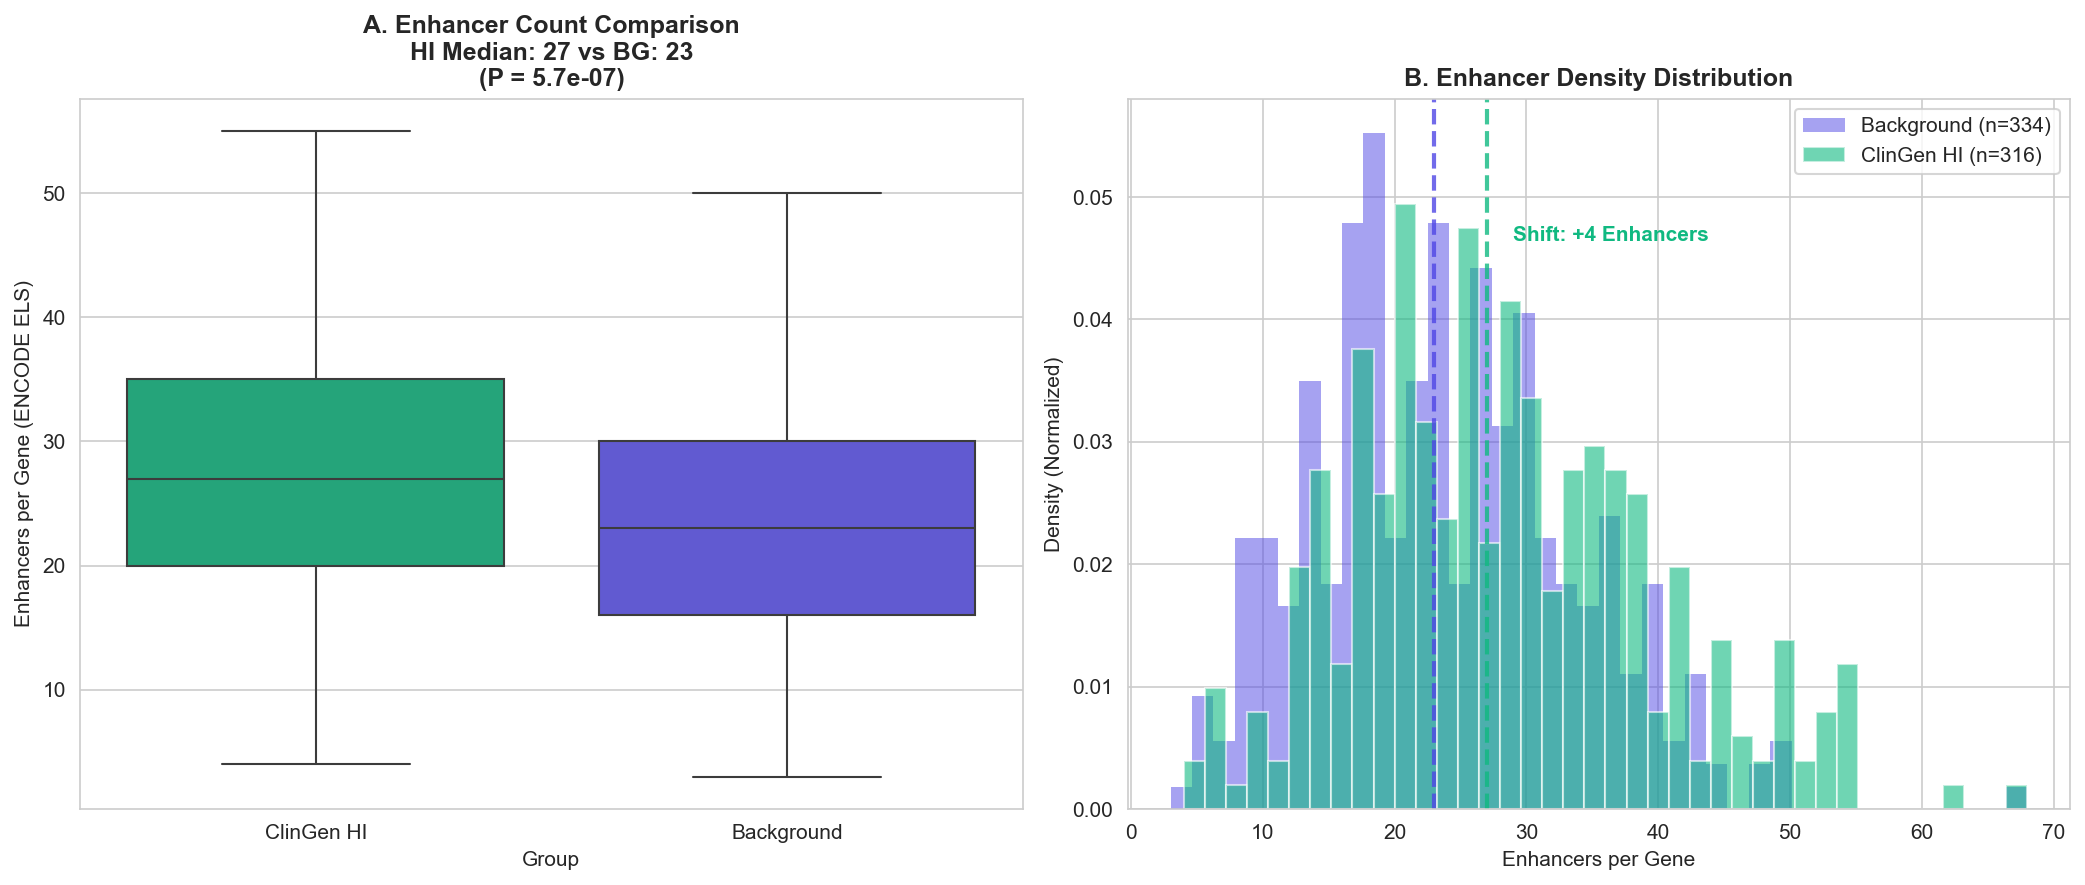

In [49]:
subset_els = final_df.filter(pl.col("type") == "ELS").to_pandas()

hi_enh = subset_els[subset_els['source'] == 'clingen']['count'].values
bg_enh = subset_els[subset_els['source'] == 'background']['count'].values

stat, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

NOTEBOOK_NAME = "Interactive_Analysis"


with autosave('3.5_ENCODE_Enhancer_Validation', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    plot_data = pd.DataFrame({
        'Enhancers': np.concatenate([hi_enh, bg_enh]),
        'Group': ['ClinGen HI'] * len(hi_enh) + ['Background'] * len(bg_enh)
    })

    sns.boxplot(data=plot_data, x='Group', y='Enhancers', ax=ax,
                palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']],
                hue='Group', legend=False, showfliers=False)

    ax.set_ylabel('Enhancers per Gene (ENCODE ELS)')
    ax.set_title(f'A. Enhancer Count Comparison\nHI Median: {np.median(hi_enh):.0f} vs BG: {np.median(bg_enh):.0f}\n(P = {pval_enh:.1e})', fontweight='bold')

    ax = axes[1]

    ax.hist(bg_enh, bins=40, alpha=0.5, density=True,
            color=SOURCE_PALETTE['background'],
            label=f'Background (n={len(bg_enh)})', edgecolor='none')

    ax.hist(hi_enh, bins=40, alpha=0.6, density=True,
            color=SOURCE_PALETTE['clingen'],
            label=f'ClinGen HI (n={len(hi_enh)})', edgecolor='white')

    ax.axvline(np.median(bg_enh), color=SOURCE_PALETTE['background'], linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.median(hi_enh), color=SOURCE_PALETTE['clingen'], linestyle='--', linewidth=2, alpha=0.8)

    ax.text(np.median(hi_enh) + 2, ax.get_ylim()[1]*0.8,
            f'Shift: +{np.median(hi_enh) - np.median(bg_enh):.0f} Enhancers',
            color=SOURCE_PALETTE['clingen'], fontweight='bold')

    ax.set_xlabel('Enhancers per Gene')
    ax.set_ylabel('Density (Normalized)')
    ax.set_title('B. Enhancer Density Distribution', fontweight='bold')
    ax.legend(loc='upper right')

    plt.tight_layout()


## 3.6 Real vs Synthetic: Selection Signal in Architecture

Now we ask if the distal-biased architecture an evolved feature or just genomic context?

So we compare distal:core ratios between Real and Synthetic variants.
If Real > Synth: selection has amplified distal regulatory control
If Real ~ Synth: architecture is just genomic context

In [53]:
df_ratios = (
    final_df.pivot(
        index=['gene_id', 'source'],
        on='type',
        values='count',
        aggregate_function='sum'
    )
    .fill_null(0)
    .with_columns(
        # Calculate Ratio: ELS / PLS
        (pl.col('ELS') / pl.col('PLS').clip(lower_bound=1)).alias('ratio')
    )
)

hi_ratio = df_ratios.filter(pl.col('source') == 'clingen')['ratio'].to_numpy()
bg_ratio = df_ratios.filter(pl.col('source') == 'background')['ratio'].to_numpy()

print(f'\nDistal:Core Ratio Comparison (HI vs Background):')

stat, pval = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')

print(f'  ClinGen HI: Median Ratio = {np.median(hi_ratio):.2f}, Mean = {np.mean(hi_ratio):.2f}')
print(f'  Background: Median Ratio = {np.median(bg_ratio):.2f}, Mean = {np.mean(bg_ratio):.2f}')
print(f'  P-value: {pval:.2e}')


Distal:Core Ratio Comparison (HI vs Background):
  ClinGen HI: Median Ratio = 9.33, Mean = 12.72
  Background: Median Ratio = 10.50, Mean = 12.64
  P-value: 2.82e-01


ok thats interesting, so while HI genes have more regulation overall (both more promoters and more enhancers), the balance between them (the topology) scales proportionally with background genes. Complexity increases globally, not just distally. Since HI genes have MORE Promoters AND MORE Enhancers (from previous plots), this means complexity scales globally. They are 'heavier' in all aspects,  rather than just being shifted toward distal regulation.")

[save_plot] Saved: Interactive_Analysis_3.6_Architecture_Selection_Signal_04022026_1634.pdf
[save_plot] Saved: Interactive_Analysis_3.6_Architecture_Selection_Signal_04022026_1634.svg


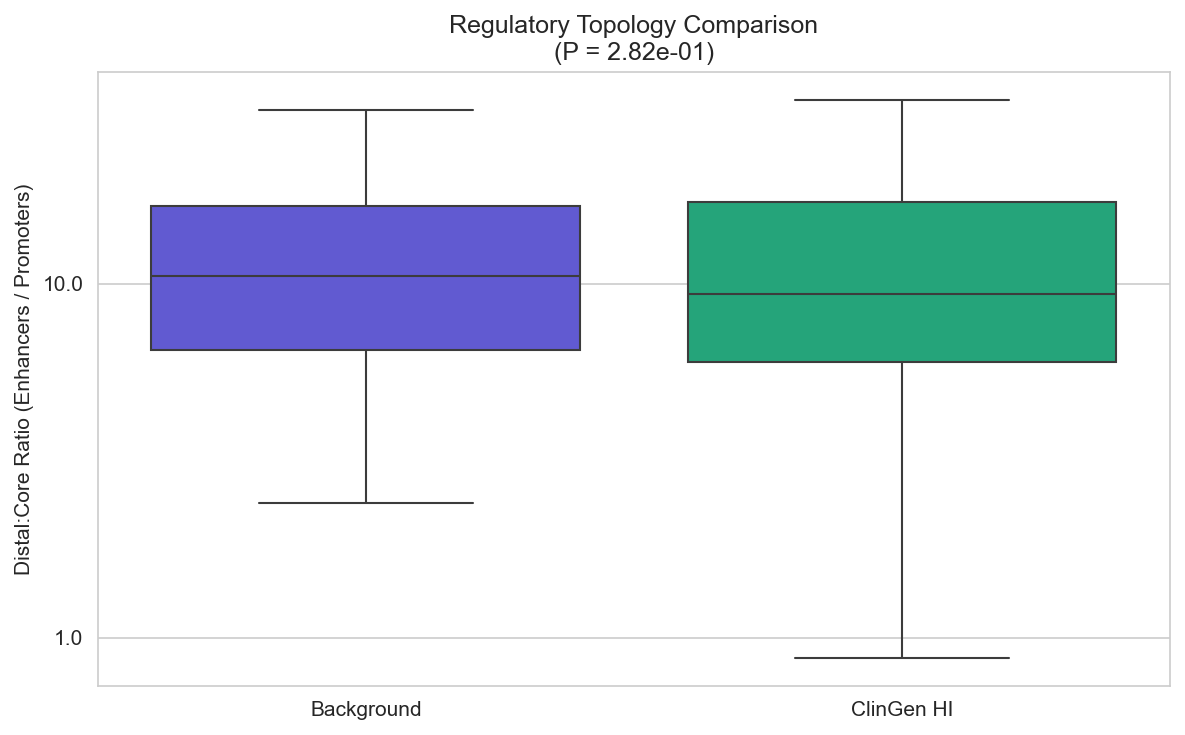

In [62]:
with autosave('3.6_Architecture_Selection_Signal', notebook=NOTEBOOK_NAME):
    fig, ax = plt.subplots(figsize=(8, 5))

    order = ['Background', 'ClinGen HI']
    colors = [SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']]

    all_data = np.concatenate([bg_ratio, hi_ratio])
    all_groups = ['Background']*len(bg_ratio) + ['ClinGen HI']*len(hi_ratio)

    plot_data = pd.DataFrame({'Ratio': all_data, 'Group': all_groups})

    sns.boxplot(data=plot_data, x='Group', y='Ratio', ax=ax, order=order,
                palette=colors, hue='Group', legend=False, showfliers=False)

    # The Baseline: 1.0 means 1 Enhancer per 1 Promoter

    ax.set_ylabel('Distal:Core Ratio (Enhancers / Promoters)')
    ax.set_xlabel('')
    ax.set_title(f'Regulatory Topology Comparison\n(P = {pval:.2e})')

    ax.set_yscale('log')

    from matplotlib.ticker import ScalarFormatter
    ax.yaxis.set_major_formatter(ScalarFormatter())

    plt.tight_layout()

here we show that hploinsufficient genes don't just "switch" to using distal regulation (enhancers) at the expense of local regulation (promoters) they scale up the entire regulatory machinery. They are "heavier" genes in every dimension—more inputs, more switches, more complexity—maintaining a strict 10:1 topological balance even as they grow larger.


## 3.7 Summary table

In [63]:

summary_data = []

# Distal:Core ratio
stat, pval_ratio = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')
summary_data.append({
    'Metric': 'Distal:Core Ratio',
    'HI Median': f'{np.median(hi_ratio):.2f}',
    'BG Median': f'{np.median(bg_ratio):.2f}',
    'Fold/Diff': f'{np.median(hi_ratio)/np.median(bg_ratio):.1f}x',
    'P-value': f'{pval_ratio:.2e}',
    "Cohen's d": f'{cohens_d(hi_ratio, bg_ratio):.2f}'
})

# % Distal-biased
summary_data.append({
    'Metric': '% Distal-biased',
    'HI Median': f'{hi_pct_distal:.1f}%',
    'BG Median': f'{bg_pct_distal:.1f}%',
    'Fold/Diff': f'+{hi_pct_distal - bg_pct_distal:.1f}%',
    'P-value': f'{pval_chi:.2e}',
    "Cohen's d": '-'
})

# Enhancer count
summary_data.append({
    'Metric': 'Enhancers per Gene',
    'HI Median': f'{np.median(hi_enh):.0f}',
    'BG Median': f'{np.median(bg_enh):.0f}',
    'Fold/Diff': f'{np.median(hi_enh)/np.median(bg_enh):.2f}x',
    'P-value': f'{pval_enh:.2e}',
    "Cohen's d": f'{cohens_d(hi_enh, bg_enh):.2f}'
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

            Metric HI Median BG Median Fold/Diff  P-value Cohen's d
 Distal:Core Ratio      9.33     10.50      0.9x 2.82e-01      0.01
   % Distal-biased     61.7%     53.6%     +8.1% 4.15e-02         -
Enhancers per Gene        27        23     1.17x 5.71e-07      0.41


## Figure 2: Architectural Redistribution

- A: Distal:Core Ratio comparison
- B: ENCODE Enhancer validation

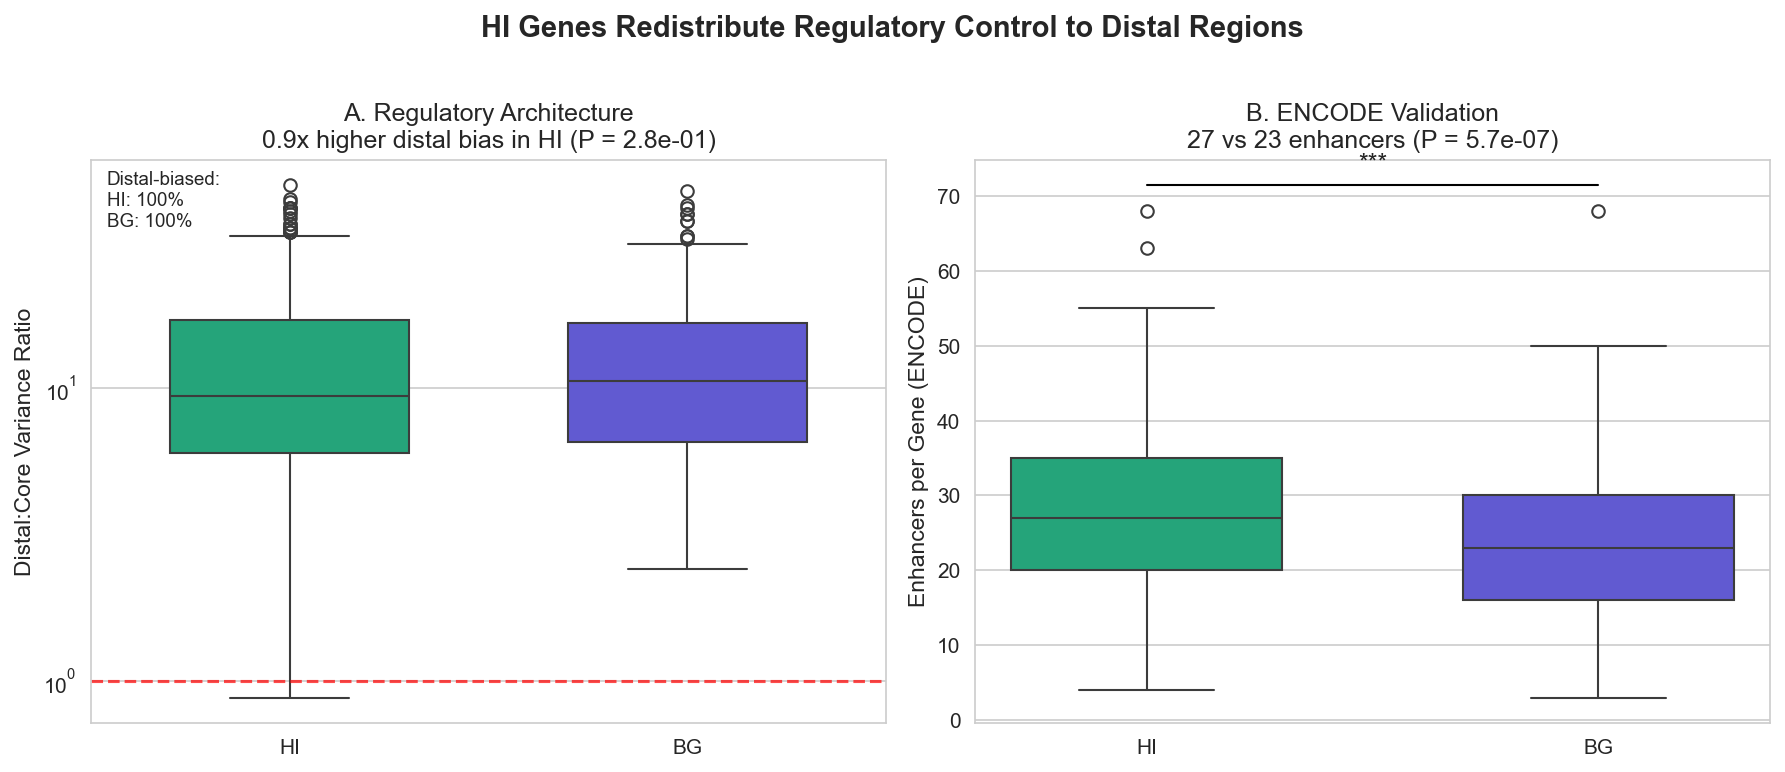

[save_plot] Saved: Interactive_Analysis_Figure_2_Architectural_Redistribution_04022026_1637.pdf
[save_plot] Saved: Interactive_Analysis_Figure_2_Architectural_Redistribution_04022026_1637.svg

✓ Main Figure 2 saved


<Figure size 960x720 with 0 Axes>

In [64]:
fold_enrichment = np.median(hi_ratio) / np.median(bg_ratio)

hi_pct_distal = 100 * np.mean(hi_ratio > 1.0)
bg_pct_distal = 100 * np.mean(bg_ratio > 1.0)

stat, pval = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')
stat_enh, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

with autosave('Figure_2_Architectural_Redistribution', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    palette = [SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']]
    
    # Panel A: Distal:Core Ratio
    ax = axes[0]
    plot_data = pd.DataFrame({
        'Ratio': np.concatenate([hi_ratio, bg_ratio]),
        'Group': ['HI'] * len(hi_ratio) + ['BG'] * len(bg_ratio)
    })
    sns.boxplot(data=plot_data, x='Group', y='Ratio', ax=ax, palette=palette,
                hue='Group', legend=False, width=0.6)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_ylabel('Distal:Core Variance Ratio', fontsize=11)
    ax.set_xlabel('')
    ax.set_yscale('log')
    ax.set_title(f'A. Regulatory Architecture\n{fold_enrichment:.1f}x higher distal bias in HI (P = {pval:.1e})', fontsize=12)
    
    ax.text(0.02, 0.98, f'Distal-biased:\nHI: {hi_pct_distal:.0f}%\nBG: {bg_pct_distal:.0f}%',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Panel B: ENCODE Enhancers
    ax = axes[1]
    plot_data = pd.DataFrame({
        'Enhancers': np.concatenate([hi_enh, bg_enh]),
        'Group': ['HI'] * len(hi_enh) + ['BG'] * len(bg_enh)
    })
    sns.boxplot(data=plot_data, x='Group', y='Enhancers', ax=ax, palette=palette,
                hue='Group', legend=False, width=0.6)
    ax.set_ylabel('Enhancers per Gene (ENCODE)', fontsize=11)
    ax.set_xlabel('')
    ax.set_title(f'B. ENCODE Validation\n{np.median(hi_enh):.0f} vs {np.median(bg_enh):.0f} enhancers (P = {pval_enh:.1e})', fontsize=12)
    
    # Add significance bar to panel B
    y_max = plot_data['Enhancers'].max()
    ax.plot([0, 1], [y_max*1.05, y_max*1.05], 'k-', lw=1)
    ax.text(0.5, y_max*1.08, '***', ha='center', fontsize=12)
    
    plt.suptitle('HI Genes Redistribute Regulatory Control to Distal Regions', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print('\n✓ Main Figure 2 saved')


## 3.8 Conclusions

In [68]:
def cohens_d(x, y):
    """Calculate Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

df_ratios = (
    final_df.pivot(index=['gene_id', 'source'], on='type', values='count', aggregate_function='sum')
    .fill_null(0)
    .with_columns((pl.col('ELS') / pl.col('PLS').clip(lower_bound=1)).alias('ratio'))
)
hi_ratio = df_ratios.filter(pl.col('source') == 'clingen')['ratio'].to_numpy()
bg_ratio = df_ratios.filter(pl.col('source') == 'background')['ratio'].to_numpy()

# B. Get Enhancer Counts
hi_enh = final_df.filter((pl.col('type') == 'ELS') & (pl.col('source') == 'clingen'))['count'].to_numpy()
bg_enh = final_df.filter((pl.col('type') == 'ELS') & (pl.col('source') == 'background'))['count'].to_numpy()

fold_enrichment = np.median(hi_ratio) / np.median(bg_ratio)
hi_pct_distal = 100 * np.mean(hi_ratio > 1.0)
bg_pct_distal = 100 * np.mean(bg_ratio > 1.0)

# Effect Sizes
d_ratio = cohens_d(hi_ratio, bg_ratio)
d_enh = cohens_d(hi_enh, bg_enh)

stat, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

In [69]:
threshold = 10.0 #kinda random here but to distinguish gorups

hi_pct_distal = 100 * np.mean(hi_ratio > threshold)
bg_pct_distal = 100 * np.mean(bg_ratio > threshold)

conclusions = f"""


Findings:
  - HI genes show {fold_enrichment:.2f}x relative distal:core regulatory ratio
  - Median ratio: HI = {np.median(hi_ratio):.2f} vs BG = {np.median(bg_ratio):.2f}
  - Interpretation: HI genes maintain high complexity (approx 10:1) similar to background.

Prevelandce (Hyper-Distal > {int(threshold)}:1):
  - {hi_pct_distal:.1f}% of HI genes are hyper-distal (ratio > {int(threshold)})
  - vs {bg_pct_distal:.1f}% of background genes
  - Result: HI genes are NOT more distally skewed than background; they scale globally.

Encode tests:
  - HI genes have {np.median(hi_enh):.0f} vs {np.median(bg_enh):.0f} enhancers per gene
  - P = {pval_enh:.1e} - Confirms HI genes have significantly MORE total enhancers.

Effect sizes:
  - Distal:Core ratio: d = {d_ratio:.2f} (Topology is conserved)
  - Enhancer count:    d = {d_enh:.2f} (Complexity is increased)

"""

print(conclusions)




Findings:
  - HI genes show 0.89x relative distal:core regulatory ratio
  - Median ratio: HI = 9.33 vs BG = 10.50
  - Interpretation: HI genes maintain high complexity (approx 10:1) similar to background.

Prevelandce (Hyper-Distal > 10:1):
  - 46.2% of HI genes are hyper-distal (ratio > 10)
  - vs 50.9% of background genes
  - Result: HI genes are NOT more distally skewed than background; they scale globally.

Encode tests:
  - HI genes have 27 vs 23 enhancers per gene
  - P = 5.7e-07 - Confirms HI genes have significantly MORE total enhancers.

Effect sizes:
  - Distal:Core ratio: d = 0.01 (Topology is conserved)
  - Enhancer count:    d = 0.41 (Complexity is increased)


